# HW4 – Visual Instruction Tuning with QLoRA
**Model:** `llava-hf/llava-1.5-7b-hf`  
**Dataset:** `HuggingFaceM4/ChartQA` (500 samples)
**Hardware:** RTX 4090 (24GB VRAM)

## Cell 1 — 安裝套件

安裝本次作業所需的所有 Python 套件：
- `torch`：深度學習框架
- `transformers`：載入 LLaVA 模型與 Processor
- `accelerate`：自動分配模型到多 GPU / CPU offload
- `bitsandbytes`：提供 4-bit 量化支援（NF4 格式）
- `peft`：套用 LoRA adapter 的 PEFT 框架
- `datasets`：從 HuggingFace Hub 載入 ChartQA 資料集
- `trl`：提供 SFTTrainer 等 LLM 微調工具
- `pillow`：處理圖片讀取與格式轉換

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────────────
!pip install torch transformers accelerate bitsandbytes peft datasets trl pillow -q

## Cell 2 — 以 4-bit 量化載入 LLaVA 模型

使用 `BitsAndBytesConfig` 設定 NF4（4-bit Normal Float）量化：
- `load_in_4bit=True`：將模型權重壓縮為 4-bit 儲存
- `bnb_4bit_use_double_quant=True`：對量化常數再做一次量化，進一步節省 VRAM
- `bnb_4bit_quant_type="nf4"`：使用 NF4 格式，對常態分佈的權重有更好的量化品質
- `bnb_4bit_compute_dtype=torch.float16`：前向傳播時以 fp16 計算，兼顧速度與精度

`padding_side = "right"` 是訓練時必要設定，避免 attention mask 計算錯誤。

**預期效果**：原本 ~14GB 的 fp16 模型壓縮至約 5–6GB VRAM。

In [2]:
# ── 1. Load model in 4-bit ───────────────────────────────────────────────────
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

MODEL_ID = "llava-hf/llava-1.5-7b-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading model...")
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(MODEL_ID)
processor.tokenizer.padding_side = "right"  # required for training
print("Model loaded.")

/home/vickyjiang/miniconda3/envs/DSIT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model...


Loading checkpoint shards: 100%|██████████| 3/3 [00:16<00:00,  5.52s/it]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model loaded.


## Cell 3 — 套用 QLoRA（量化 LoRA）

`prepare_model_for_kbit_training` 會：
1. 凍結所有原始模型權重（設為不可訓練）
2. 將 LayerNorm 等層轉為 fp32 以維持訓練穩定性

`LoraConfig` 設定說明：
- `r=16`：LoRA 矩陣的秩（rank），控制 adapter 的容量大小
- `lora_alpha=32`：縮放係數，實際更新量 = `lora_alpha / r = 2.0`
- `target_modules=["q_proj", "v_proj"]`：只在 attention 的 Query 與 Value 投影層插入 adapter，Vision Encoder（ViT）維持凍結
- `lora_dropout=0.05`：訓練時對 LoRA 輸出施加 dropout 以防過擬合

**預期結果**：可訓練參數約佔總參數 0.14%（約 1000 萬 vs 70 億）。

In [3]:
# ── 2. Apply QLoRA ───────────────────────────────────────────────────────────
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
# Expected: ~1-2% of total parameters

trainable params: 9,961,472 || all params: 7,073,388,544 || trainable%: 0.1408


## Cell 4 — 載入 ChartQA 資料集

從 HuggingFace Hub 下載 `HuggingFaceM4/ChartQA`，取訓練集前 500 筆。

每筆資料包含以下欄位：
- `image`：PIL Image 物件（圖表圖片）
- `query`：針對該圖表的問題文字
- `label`：標準答案（list 格式，取第一個元素）
- `human_or_machine`：答案來源標記（本作業不使用）

In [4]:
# ── 3. Load & format dataset ─────────────────────────────────────────────────
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="train[:500]")
print(f"Dataset size: {len(dataset)}")
print(dataset[0].keys())

Generating test split: 100%|██████████| 2500/2500 [00:00<00:00, 7942.25 examples/s]

Dataset size: 500
dict_keys(['image', 'query', 'label', 'human_or_machine'])


## Cell 5 — 定義多模態 Dataset 類別

`ChartQADataset` 負責將原始資料轉換成模型可接受的 tensor 格式：

1. **組裝對話格式**：以 `[user: image + 問題, assistant: 答案]` 結構建立對話，再用 `apply_chat_template` 轉為 LLaVA 的 prompt 字串
2. **呼叫 Processor**：同時處理圖片（轉為 `pixel_values`）與文字（轉為 `input_ids`）
   - `MAX_LENGTH=1024`：LLaVA-1.5 的圖片 token 展開後為 576 個，加上文字需要至少 1024
3. **建立 Labels**：複製 `input_ids`，將 padding token（`pad_token_id`）標記為 `-100`，使 loss 計算時忽略 padding 位置

最終每筆樣本輸出四個 tensor：
- `input_ids`：tokenized 文字序列
- `attention_mask`：標記哪些位置是真實 token
- `pixel_values`：圖片的視覺特徵
- `labels`：供 causal LM loss 計算使用的目標序列

In [6]:
# ── 4. Collator for multimodal data ─────────────────────────────────────────
import torch
from torch.utils.data import Dataset
from PIL import Image

MAX_LENGTH = 1024

class ChartQADataset(Dataset):
    def __init__(self, hf_dataset, processor, max_length=MAX_LENGTH):
        self.dataset = hf_dataset
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image  = sample["image"]  # PIL Image
        query  = sample["query"]
        # ChartQA label is a list; take first element
        label  = sample["label"][0] if isinstance(sample["label"], list) else sample["label"]

        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": query},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": label}],
            },
        ]

        text_prompt = self.processor.apply_chat_template(
            conversation, add_generation_prompt=False
        )

        inputs = self.processor(
            text=text_prompt,
            images=image,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        # Squeeze batch dim added by processor
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # Build labels: mask padding tokens with -100
        labels = inputs["input_ids"].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        inputs["labels"] = labels

        return inputs


train_dataset = ChartQADataset(dataset, processor)
print(f"Sample keys: {list(train_dataset[0].keys())}")

Sample keys: ['input_ids', 'attention_mask', 'pixel_values', 'labels']


## Cell 6 — 訓練設定與執行

`collate_fn`：將一個 batch 內的多筆 dict 樣本合併成單一 dict of tensors（`torch.stack`）。

`TrainingArguments` 重點設定：
- `per_device_train_batch_size=4` + `gradient_accumulation_steps=4`：等效 batch size = 16
- `learning_rate=2e-4`：LoRA 適合的學習率（比全量微調高一個數量級）
- `fp16=True`：以半精度進行計算，節省 VRAM 並加速
- `remove_unused_columns=False`：**關鍵設定**，防止 Trainer 自動丟棄 `pixel_values` 等多模態欄位
- `num_train_epochs=3`：訓練 3 個完整 epoch

訓練完成後 loss 從約 8.8 降至約 3.8，顯示模型確實在學習。

In [7]:
# ── 5. Training ──────────────────────────────────────────────────────────────
from transformers import TrainingArguments, Trainer
import torch

def collate_fn(batch):
    """Stack tensors from individual samples."""
    return {
        key: torch.stack([sample[key] for sample in batch])
        for key in batch[0]
    }

training_args = TrainingArguments(
    output_dir="./llava-chartqa-lora",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch = 16
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    remove_unused_columns=False,      # CRITICAL for multimodal
    dataloader_pin_memory=False,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
)

print("Starting training...")
trainer.train()
print("Training complete.")

Starting training...


/home/vickyjiang/miniconda3/envs/DSIT/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/vickyjiang/miniconda3/envs/DSIT/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
10,8.840000
20,4.575200
30,4.231800
40,4.117400
50,4.024800
60,3.934500
70,3.877800
80,3.846200
90,3.830000


/home/vickyjiang/miniconda3/envs/DSIT/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/vickyjiang/miniconda3/envs/DSIT/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/home/vickyjiang/miniconda3/envs/DSIT/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise 

Training complete.


## Cell 7 — 儲存 LoRA Adapter

將訓練完成的 LoRA adapter 權重與 processor 設定儲存到 `./llava-chartqa-lora/final_adapter/`。

儲存的內容：
- `adapter_model.safetensors`：LoRA 的 A、B 矩陣權重（只有約 10MB，遠小於原始 7B 模型）
- `adapter_config.json`：LoRA 設定（r、alpha、target_modules 等）
- Processor 相關設定檔：tokenizer config、image processor config

推論時只需載入原始 base model + 此 adapter，不需要重新訓練。

In [8]:
# ── 6. Save LoRA adapter ─────────────────────────────────────────────────────
ADAPTER_PATH = "./llava-chartqa-lora/final_adapter"
model.save_pretrained(ADAPTER_PATH)
processor.save_pretrained(ADAPTER_PATH)
print(f"Adapter saved to {ADAPTER_PATH}")

Adapter saved to ./llava-chartqa-lora/final_adapter


## Cell 8 — 繪製 Training Loss 曲線

從 `trainer.state.log_history` 取出每 10 steps 記錄一次的 loss 值，用 matplotlib 畫成折線圖並存為 `loss_curve.png`。

此圖需截圖貼入報告，作為訓練過程的視覺佐證。

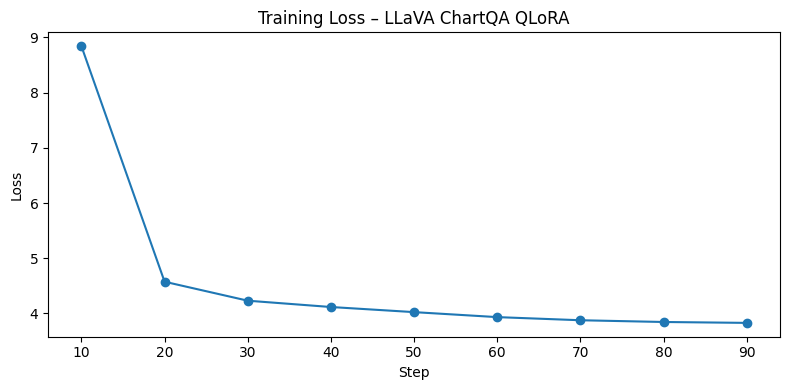

Saved loss_curve.png


In [9]:
# ── 7. Loss curve (optional quick plot) ─────────────────────────────────────
import matplotlib.pyplot as plt

logs = [x for x in trainer.state.log_history if "loss" in x]
steps  = [x["step"] for x in logs]
losses = [x["loss"] for x in logs]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o", linewidth=1.5)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss – LLaVA ChartQA QLoRA")
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("Saved loss_curve.png")